In [25]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.patches import Patch

import os
import scanpy as sc

import seaborn as sns
import snapatac2 as snap

snap.__version__


'2.9.0'

## Load Data

In [2]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_stringent_calling.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info['index'] = union_cell_info.index.map(lambda x: x + '-1')

union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,P_closed_state,stringent_cell_calling,index
atac_bc,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common,0.965116,True,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common,0.990949,True,AAACAAGCATTTCTTC-1


In [3]:
nucleosome_info_file = os.path.join(Union_cell_subdir, 'nucleosome_signal_by_cell.csv')
nucleosome_info = pd.read_csv(nucleosome_info_file, index_col=0)
nucleosome_info['index'] = nucleosome_info.index.map(lambda x: x + '-1')
nucleosome_info.head(2)

,nucleosome_signal,index
atac_bc,,
AAACAAGCAAGTTAGT,-1.552972,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,-1.926050,AAACAAGCATTTCTTC-1


In [4]:
frip_score_file = os.path.join(Union_cell_subdir, 'frip_cells_info.tsv')
frip_score_info = pd.read_csv(frip_score_file, sep='\t', index_col=0)
frip_score_info['index'] = frip_score_info.index.map(lambda x: x + '-1')
frip_score_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,Nfrag_in_raw_peaks,Nfrag_in_entropy_peaks,Nfrag_in_tss_peaks,Nfrag_in_frip_peaks,FRIP_raw_peaks,FRIP_entropy_peaks,FRIP_tss_peaks,FRIP_frip_peaks,index
atac_bc,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,1729,1919,1933,1785,71.683250,79.560531,80.140962,74.004975,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,1538,1847,1877,1635,17.032115,20.454042,20.786268,18.106312,AAACAAGCATTTCTTC-1


In [5]:
amulet_doublet_atac_file = os.path.join(Union_cell_subdir, 'AMULET_output/MultipletBarcodes_01.txt')
doublet_atac_barcodes = pd.read_csv(amulet_doublet_atac_file, header=None)
doublet_atac_barcodes.columns = ['barcodes']
doublet_atac_barcodes['atac_bc'] = doublet_atac_barcodes['barcodes'].str.split('-').str[0]
doublet_atac_barcodes.head(2)



,barcodes,atac_bc
0,AAAGCCTAGGATTATG-1,AAAGCCTAGGATTATG
1,AAAGGCGCACTAATCC-1,AAAGGCGCACTAATCC


In [6]:
os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_all_unioncells.h5ad')

'/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison/_SNAPataC_analysis/binnedGenome_all_unioncells.h5ad'

In [7]:
data = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_all_unioncells.h5ad'))

In [8]:
data.obs[(data.obs['amulet_doublet_atac'] == True) | (data.obs['DNA_debris'] == 'YES') ].groupby(['_3set_identified_by_atac']).size()

/tmp/ipykernel_3013414/2208233013.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.obs[(data.obs['amulet_doublet_atac'] == True) | (data.obs['DNA_debris'] == 'YES') ].groupby(['_3set_identified_by_atac']).size()


_3set_identified_by_atac
CR unique           22
CR+TSS, not SADE     0
SADE unique          0
SADE+CR, not TSS    11
SADE+TSS, not CR     0
TSS unique           0
common              65
dtype: int64

In [9]:
data.obs[(data.obs['amulet_doublet_atac'] == True) | (data.obs['DNA_debris'] == 'YES') ].groupby(['leiden_RNA_scVI']).size()

/tmp/ipykernel_3013414/3826379241.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.obs[(data.obs['amulet_doublet_atac'] == True) | (data.obs['DNA_debris'] == 'YES') ].groupby(['leiden_RNA_scVI']).size()


leiden_RNA_scVI
0              11
1              15
2              15
3               6
4               0
5               3
6               5
7               3
8              20
9               2
10              0
11             18
no_rna_info     0
dtype: int64

In [10]:
data_filter = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_unioncells_filtered.h5ad'))

# filtered_leiden_file = os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_unioncells_filtered_obs.csv')
# data_filter.obs[[ 'leiden', 'filtered_leiden']].to_csv(
#     filtered_leiden_file)

# Vis

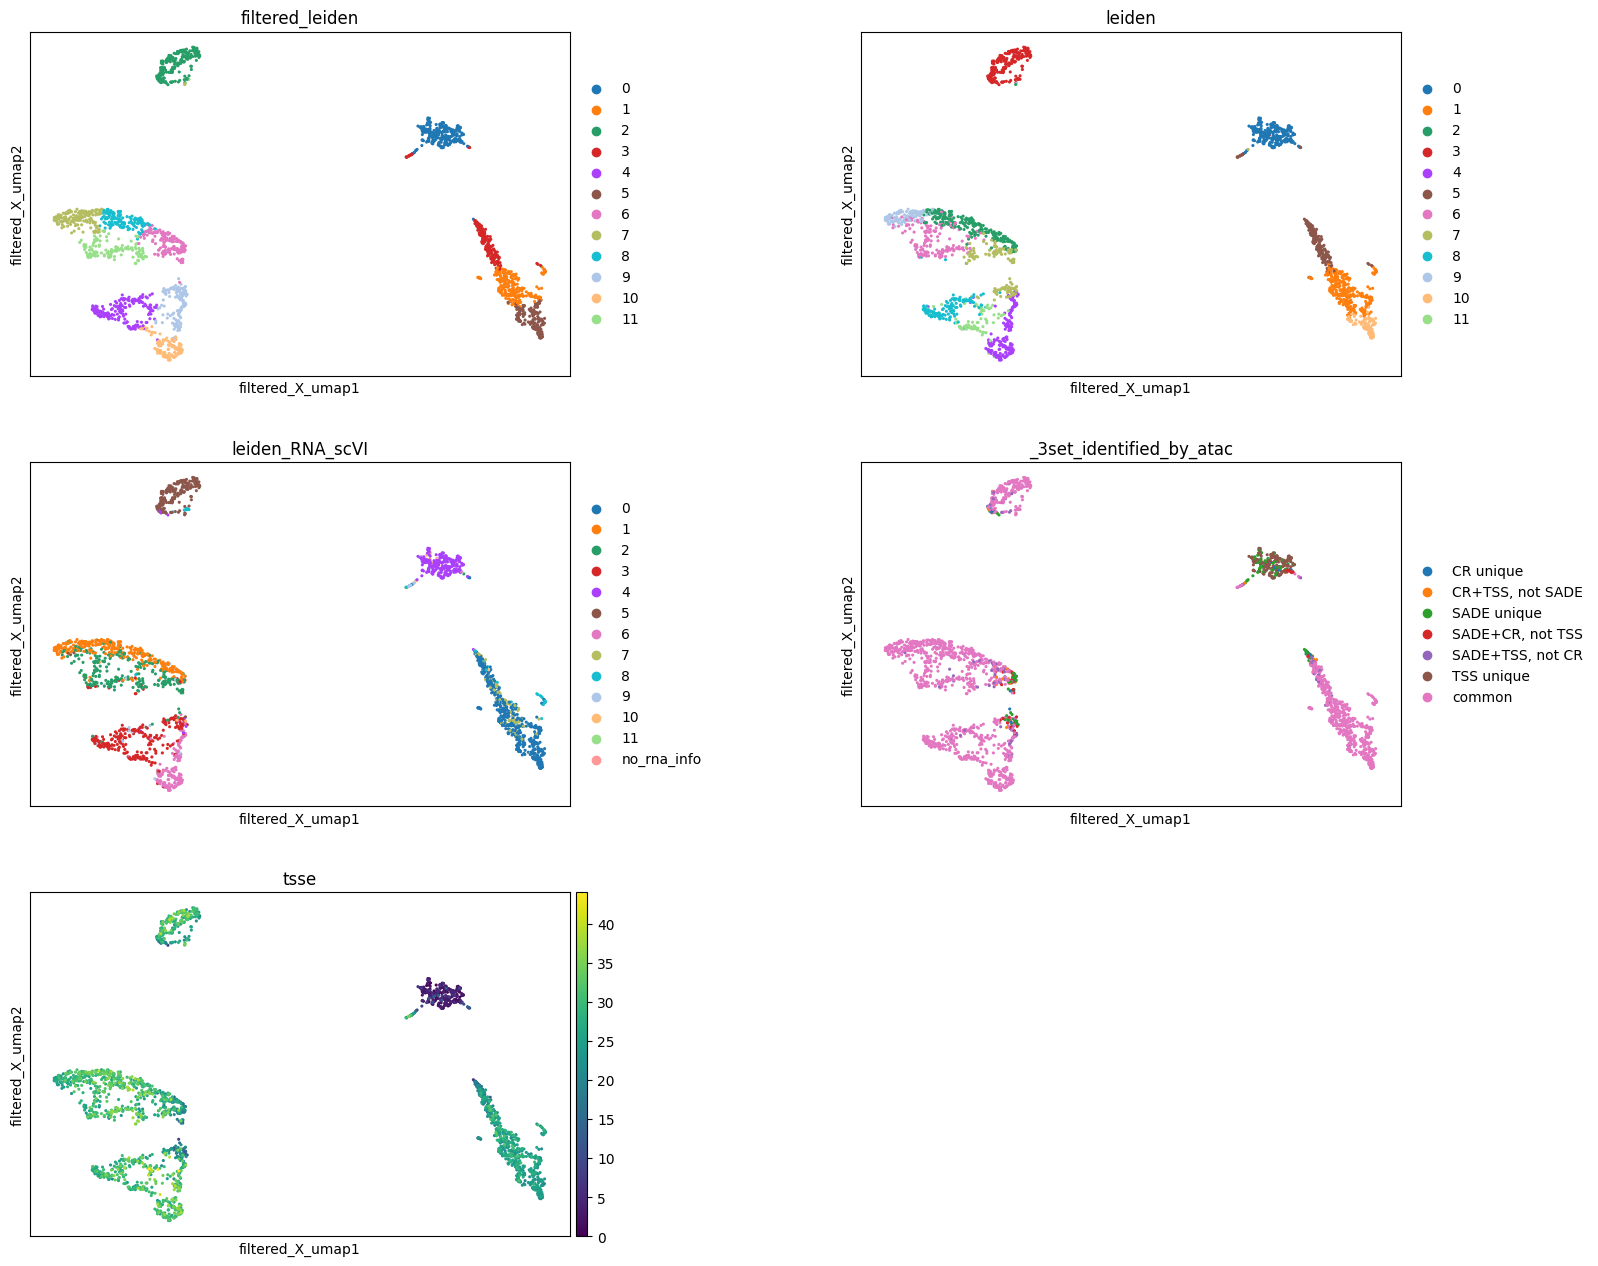

In [13]:
sc.pl.embedding(data_filter, basis='filtered_X_umap', color=['filtered_leiden', 'leiden', 'leiden_RNA_scVI', '_3set_identified_by_atac', 'tsse'], s=20, ncols=2, wspace=0.4)

# Gene activity score

In [14]:
gene_matrix = snap.pp.make_gene_matrix(data, snap.genome.hg38)
gene_matrix

AnnData object with n_obs × n_vars = 2384 × 60606
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy'

In [15]:
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)
gene_matrix

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


AnnData object with n_obs × n_vars = 2384 × 58486
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy'
    var: 'n_cells'
    uns: 'log1p'

In [16]:
gene_matrix.obsm["X_umap"] = data.obsm["X_umap"]

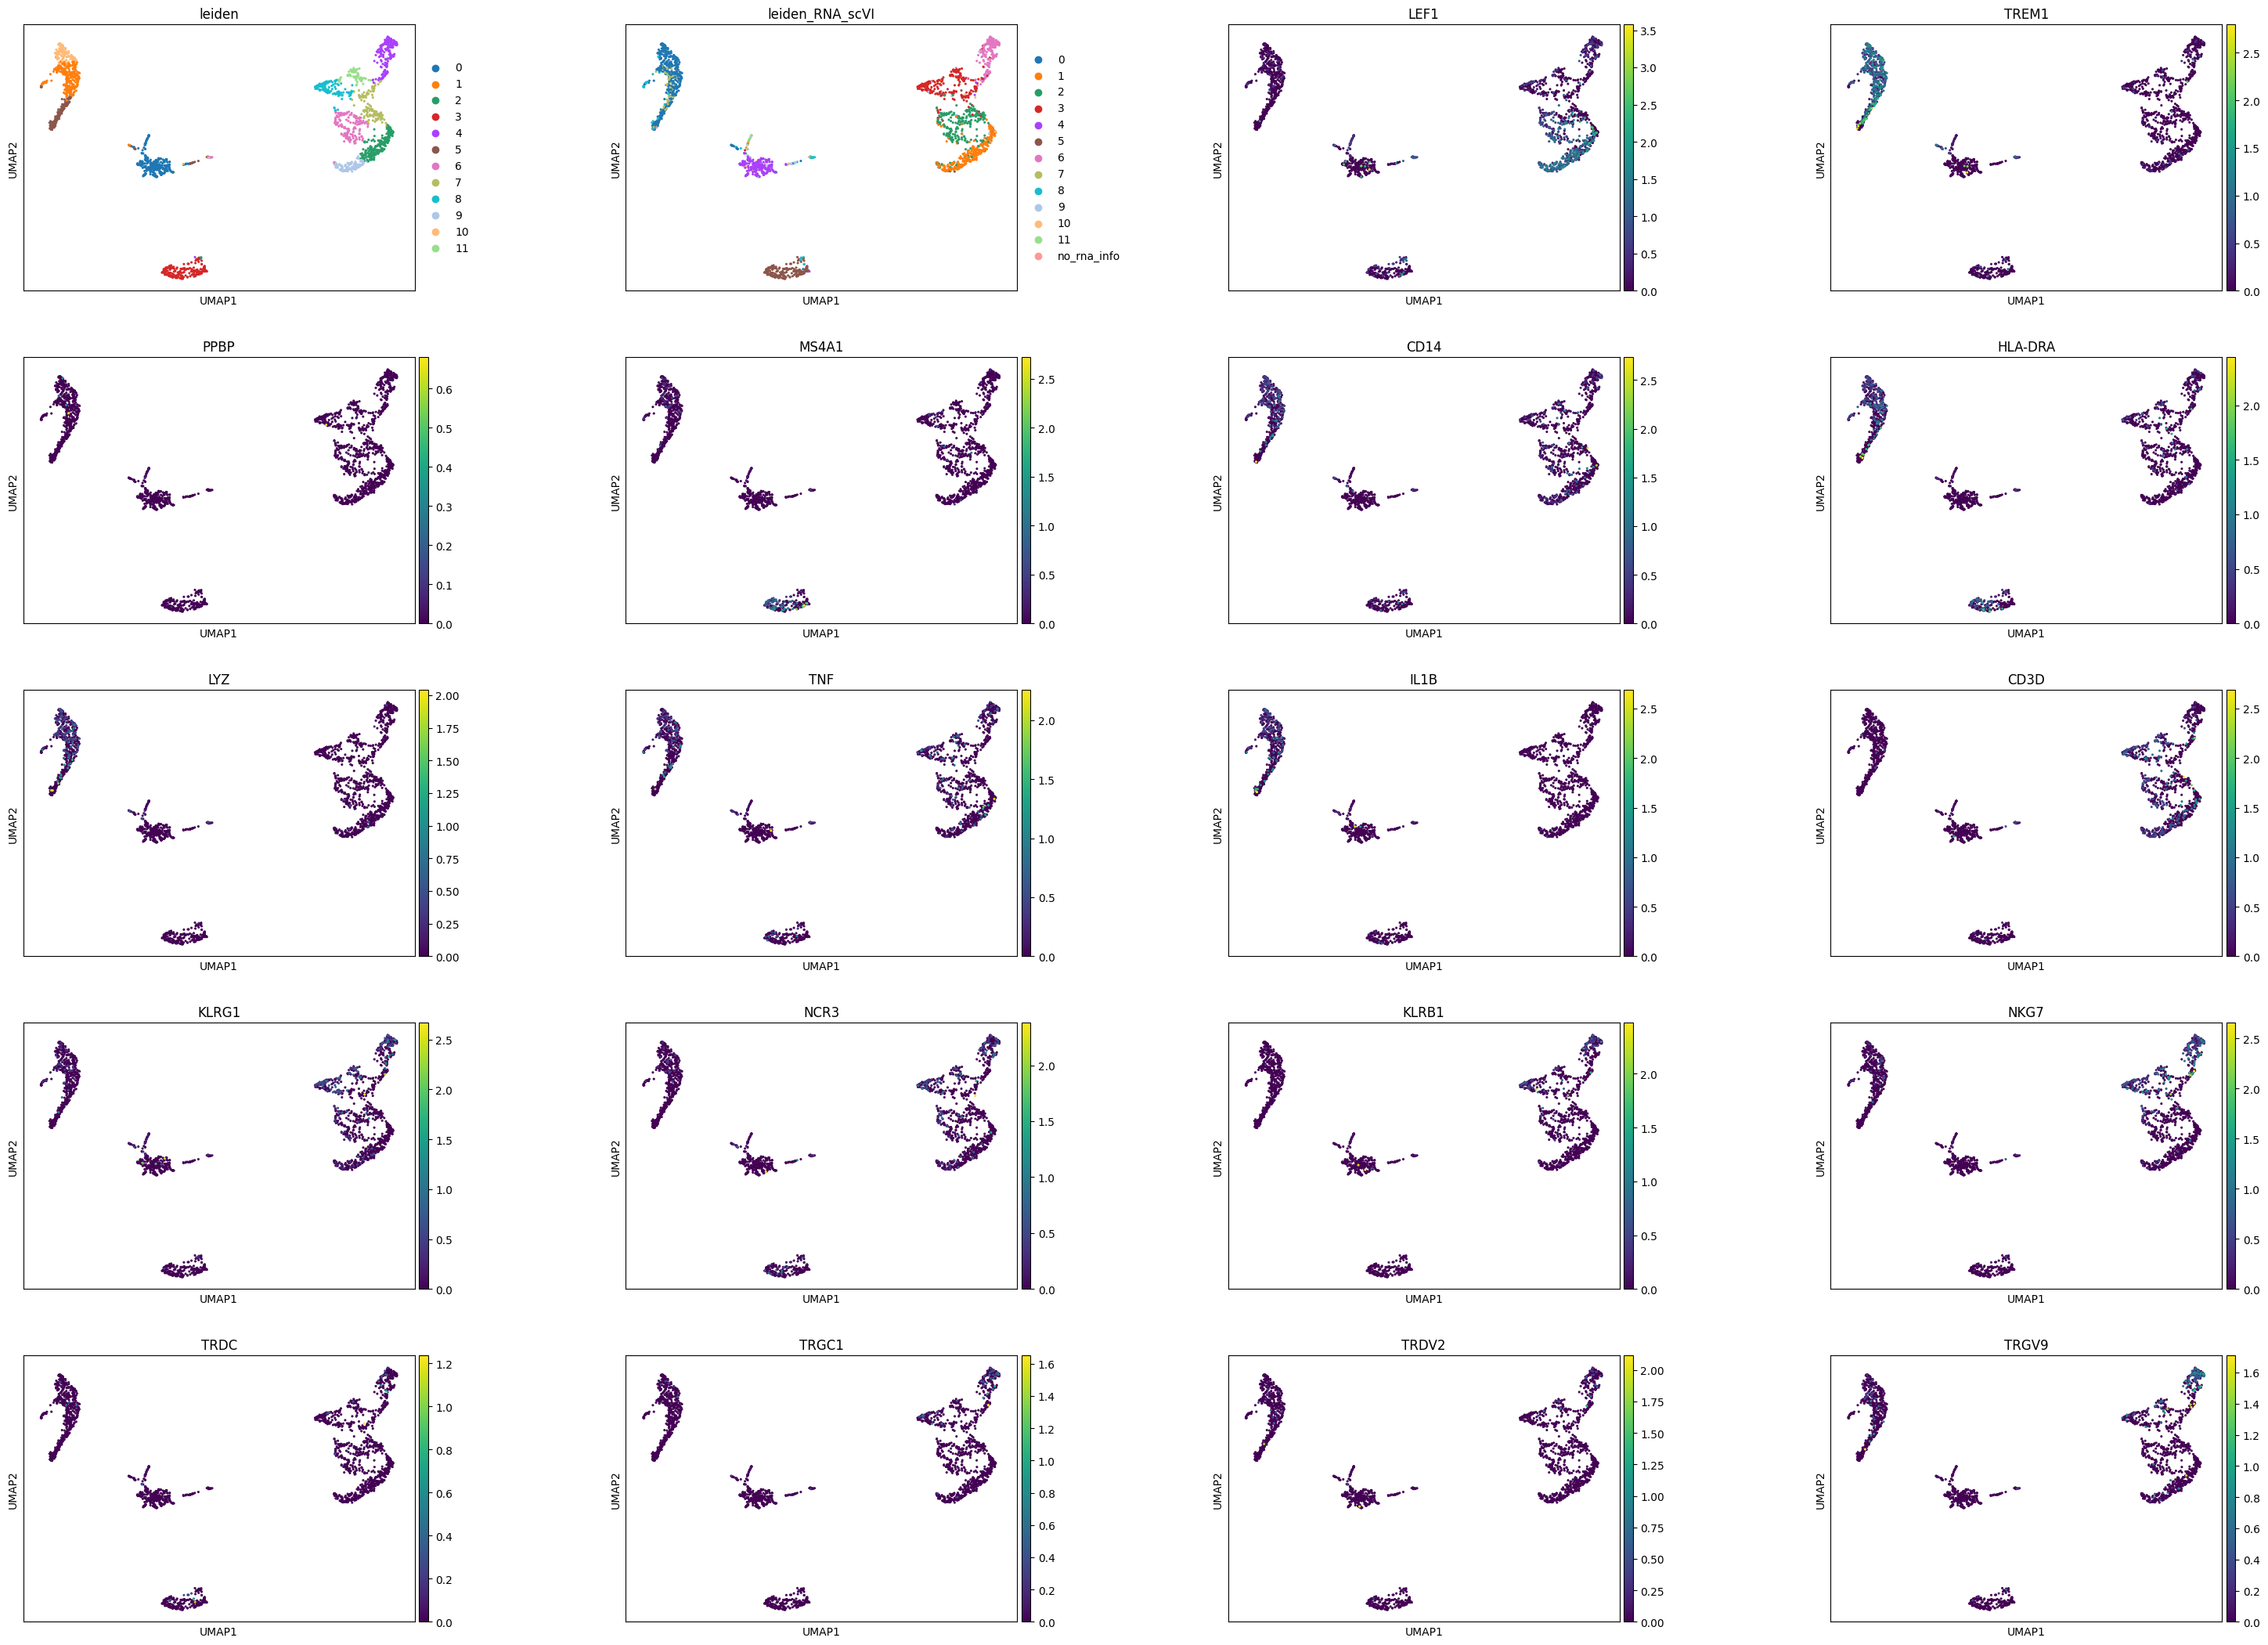

In [20]:
mono = ['CD14',   'HLA-DRA',  'LYZ', 'TNF', 'IL1B']
NK = [  'CD3D', 'KLRG1',   'NCR3','KLRB1', 'NKG7']
gamma_delta_T = ['TRDC',   'TRGC1','TRDV2', 'TRGV9']
B_cell = ['MS4A1']
marker_genes = ['LEF1',  'TREM1',  'PPBP'] + \
    B_cell + \
mono + NK + gamma_delta_T

sc.pl.umap(gene_matrix, color=['leiden', 'leiden_RNA_scVI'] + marker_genes, s=20, ncols=4, wspace=0.4)

## Vis in heatmap

In [21]:

scanpy_colors = [    
    '#1f77b4',
    '#ff7f0e', 
    '#2ca02c',
    '#d62728', 
    '#9467bd', 
    '#8c564b', 
    '#e377c2', 
    '#bcbd22', 
    '#17becf', 
    '#c7c7c7', 
    '#ffbb78',
    '#98df8a']
scanpy_cluster = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
scanpy_color_map = dict(zip(scanpy_cluster, scanpy_colors))

In [46]:
marker_genes_redor = ['LYZ', 'HLA-DRA', 'LEF1', 'NKG7','CD3D', 'MS4A1', 
                      
                      'CD14', 'TREM1', 'KLRB1', 'KLRG1', 'TRDC', 'TRGC1', 'NCR3', 'IL1B', 
                      'TRGV9', 'TNF', 'PPBP', 'TRDV2', ]

In [51]:
gene_matrix[:, marker_genes_redor]

View of AnnData object with n_obs × n_vars = 2384 × 18
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy'
    var: 'n_cells'
    uns: 'log1p', 'leiden_colors', 'leiden_RNA_scVI_colors', '_3set_identified_by_atac_colors'
    obsm: 'X_umap'

In [89]:
gene_matrix.obs['filtered_leiden'] = gene_matrix.obs.index.map(data_filter.obs['filtered_leiden']).fillna('debrisOdoublets')

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(0.5, 1.05, 'Gene activity from ATAC-seq data')

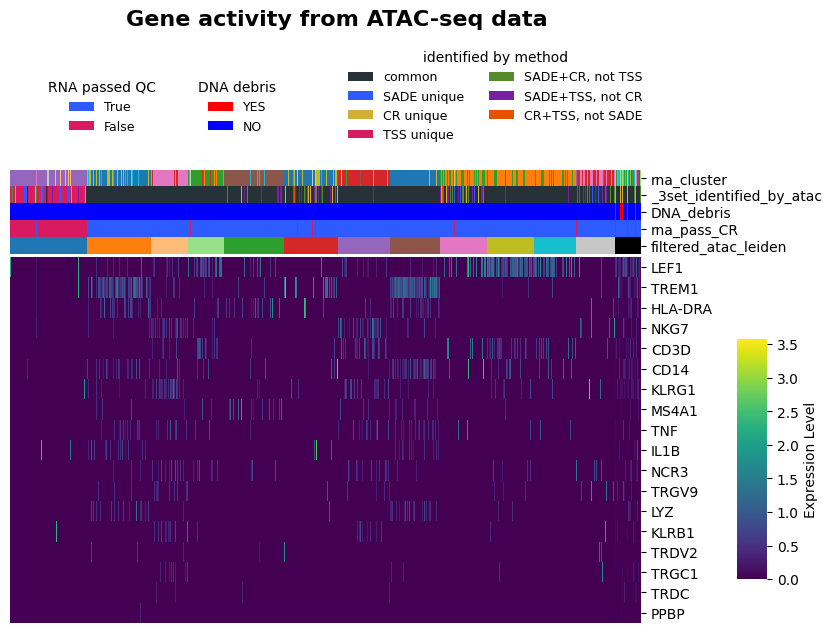

In [103]:
# heatmap 
# rows being markergens 
# columns-1 being leiden clusters
# columns-2 being the 3-set classification (e.g. 2-set identified by ATAC SC, 2-set identified by ATAC ST, 3-set identified by ATAC)
# columns-3 being pass CR preproessing or not

colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]
cat_colors_map = dict(zip(unique_categories, colors_list))                  

pass_cr_map = {True: '#2E5BFF', False: '#D81B60'}
dna_debris_map = {'YES': 'red', 'NO': 'blue'}

filtered_leiden_colors_map = dict(zip( scanpy_cluster + ['debrisOdoublets'], scanpy_colors + ['black'],))

data = gene_matrix[:, marker_genes_redor].X.toarray()
df = pd.DataFrame(data, index=gene_matrix.obs.index, columns= marker_genes_redor).T

#Create metadata for the columns
metadata = gene_matrix.obs[['leiden_RNA_scVI', '_3set_identified_by_atac', 'DNA_debris', 'rna_pass_CR', 'leiden', 'filtered_leiden']].copy()

cell_index = gene_matrix.obs['filtered_leiden'].sort_values().index


col_colors = pd.DataFrame({
    'rna_cluster': metadata['leiden_RNA_scVI'].map(scanpy_color_map),
    '_3set_identified_by_atac': metadata['_3set_identified_by_atac'].map(cat_colors_map),
    'DNA_debris': metadata['DNA_debris'].map(dna_debris_map),
    'rna_pass_CR': metadata['rna_pass_CR'].map(pass_cr_map),
    #'atac_leiden': metadata['leiden'].map(scanpy_color_map),
    'filtered_atac_leiden': metadata['filtered_leiden'].map(filtered_leiden_colors_map),
}, index=metadata.index)

# 4. Plot the clustermap
g = sns.clustermap(df.loc[:, cell_index], col_colors=col_colors.loc[cell_index], cmap='viridis', #cmap='seismic', 
                   figsize=(10, 6), col_cluster=False, xticklabels=False, row_cluster=True, 
                   cbar_pos=(0.9, 0.1, 0.03, 0.4), # Horizontal bar at bottom center
                   cbar_kws={"orientation": "vertical", 'label': 'Expression Level'}, 
                  )
g.ax_row_dendrogram.set_visible(False) # Hide Row tree


# Legend for 'rna_pass_CR'
pass_cr_handles = [
    Patch(facecolor=color, label=str(label)) 
    for label, color in pass_cr_map.items()
]
g.fig.legend(
    handles=pass_cr_handles,
    title='RNA passed QC',
    bbox_to_anchor=(0.2, 0.95), 
    loc='upper left',
    frameon=False,
    title_fontsize=10,
    fontsize=9
)
# Legend for 'DNA_debris'
dna_debris_handles = [
    Patch(facecolor=color, label=str(label))
    for label, color in dna_debris_map.items()
]
g.fig.legend(
    handles=dna_debris_handles,
    title='DNA debris',
    bbox_to_anchor=(0.35, 0.95), 
    loc='upper left',
    frameon=False,
    title_fontsize=10,
    fontsize=9
)
# legend for '_3set_identified_by_atac'
atac_set_handles = [
    Patch(facecolor=color, label=label)
    for label, color in cat_colors_map.items()
]
g.fig.legend(
    handles=atac_set_handles,
    title='identified by method',
    bbox_to_anchor=(0.5, 1), 
    loc='upper left',
    frameon=False,
    title_fontsize=10,
    fontsize=9,
    ncol=2
)

g.fig.suptitle('Gene activity from ATAC-seq data',
               fontsize=16, 
               fontweight='bold', 
               y=1.05) #

## Reorder cells to have consistency with RNA heatmap

In [83]:
rna_cell_index_file = os.path.join(Union_cell_subdir, '_unioncell_rna_order_index.csv')
rna_cell_index = pd.read_csv(rna_cell_index_file, index_col=0, header=0)
rna_cell_index['atac_barcodes-1'] = rna_cell_index['atac_barcodes'] + '-1'
rna_cell_index = rna_cell_index.set_index('atac_barcodes-1')
print(rna_cell_index.shape)
rna_cell_index.head(2)


(2381, 2)


,rna_barcodes,atac_barcodes
atac_barcodes-1,,
GTTTGGTGTGCAGTAA-1,TTTGTGGCAGTATGTT,GTTTGGTGTGCAGTAA
GGTCATGAGCTAAATG-1,GCTAGTGTCCCGTTAC,GGTCATGAGCTAAATG


In [81]:
# 3 cells do not have RNA data and only ATAC, do need to add to the index for heat map plot's consistency
for cell in gene_matrix.obs.index:
    if cell not in rna_cell_index['atac_barcodes']:
        rna_cell_index.loc[cell, 'rna_barcodes'] =None

In [82]:
rna_cell_index.tail(5)

,rna_barcodes,atac_barcodes
atac_barcodes-1,,
TGCGCCTCATCCTGCA-1,AAGTGTTGTTTCCTCC,TGCGCCTCATCCTGCA
TCCTCCATCAGGTTCC-1,TGAAGTGAGGATTGAG,TCCTCCATCAGGTTCC
CGAATAATCTCACTTC-1,NA,NaN
CGGTTTATCCTAAATC-1,NA,NaN
GTTAGGAGTGCTCATG-1,NA,NaN


Text(0.5, 1.05, 'Gene activity from ATAC-seq data')

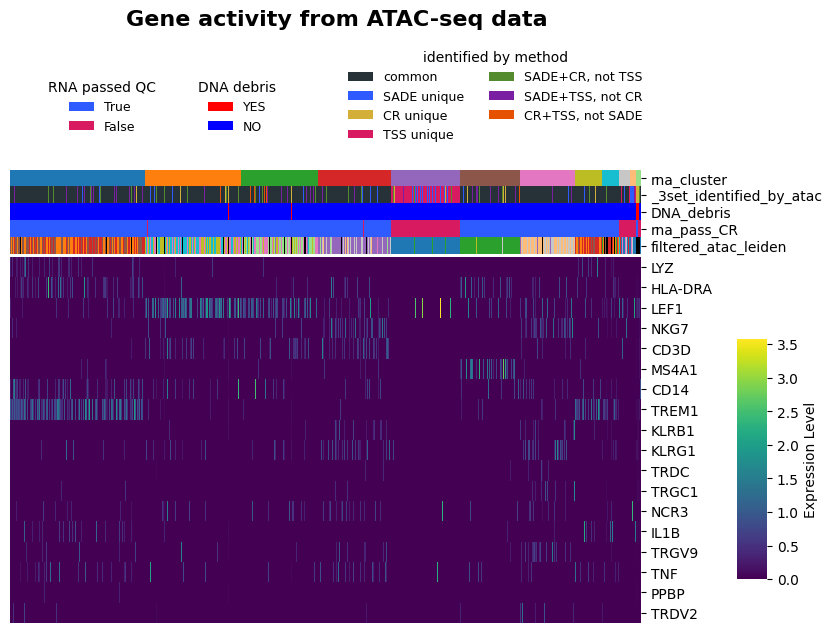

In [101]:
# heatmap 
# rows being markergens 
# columns-1 being leiden clusters
# columns-2 being the 3-set classification (e.g. 2-set identified by ATAC SC, 2-set identified by ATAC ST, 3-set identified by ATAC)
# columns-3 being pass CR preproessing or not

colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]
cat_colors_map = dict(zip(unique_categories, colors_list))                  

pass_cr_map = {True: '#2E5BFF', False: '#D81B60'}
dna_debris_map = {'YES': 'red', 'NO': 'blue'}

filtered_leiden_colors_map = dict(zip( scanpy_cluster + ['debrisOdoublets'], scanpy_colors + ['black'],))


data = gene_matrix[:, marker_genes_redor].X.toarray()
df = pd.DataFrame(data, index=gene_matrix.obs.index, columns= marker_genes_redor).T

#Create metadata for the columns
metadata = gene_matrix.obs[['leiden_RNA_scVI', '_3set_identified_by_atac', 'DNA_debris', 'rna_pass_CR', 'leiden', 'filtered_leiden']].copy()

cell_index = rna_cell_index.index
cell_index.name = None

col_colors = pd.DataFrame({
    'rna_cluster': metadata['leiden_RNA_scVI'].map(scanpy_color_map),
    '_3set_identified_by_atac': metadata['_3set_identified_by_atac'].map(cat_colors_map),
    'DNA_debris': metadata['DNA_debris'].map(dna_debris_map),
    'rna_pass_CR': metadata['rna_pass_CR'].map(pass_cr_map),
    #'atac_leiden': metadata['leiden'].map(scanpy_color_map),
    'filtered_atac_leiden': metadata['filtered_leiden'].map(filtered_leiden_colors_map),
}, index=metadata.index)

# 4. Plot the clustermap
g = sns.clustermap(df.loc[:, cell_index], col_colors=col_colors.loc[cell_index], cmap='viridis', #cmap='seismic', 
                   figsize=(10, 6), col_cluster=False, xticklabels=False, row_cluster=False, 
                   cbar_pos=(0.9, 0.1, 0.03, 0.4), # Horizontal bar at bottom center
                   cbar_kws={"orientation": "vertical", 'label': 'Expression Level'}, 
                  )
g.ax_row_dendrogram.set_visible(False) # Hide Row tree


# Legend for 'rna_pass_CR'
pass_cr_handles = [
    Patch(facecolor=color, label=str(label)) 
    for label, color in pass_cr_map.items()
]
g.fig.legend(
    handles=pass_cr_handles,
    title='RNA passed QC',
    bbox_to_anchor=(0.2, 0.95), 
    loc='upper left',
    frameon=False,
    title_fontsize=10,
    fontsize=9
)
# Legend for 'DNA_debris'
dna_debris_handles = [
    Patch(facecolor=color, label=str(label))
    for label, color in dna_debris_map.items()
]
g.fig.legend(
    handles=dna_debris_handles,
    title='DNA debris',
    bbox_to_anchor=(0.35, 0.95), 
    loc='upper left',
    frameon=False,
    title_fontsize=10,
    fontsize=9
)
# legend for '_3set_identified_by_atac'
atac_set_handles = [
    Patch(facecolor=color, label=label)
    for label, color in cat_colors_map.items()
]
g.fig.legend(
    handles=atac_set_handles,
    title='identified by method',
    bbox_to_anchor=(0.5, 1), 
    loc='upper left',
    frameon=False,
    title_fontsize=10,
    fontsize=9,
    ncol=2
)

g.fig.suptitle('Gene activity from ATAC-seq data',
               fontsize=16, 
               fontweight='bold', 
               y=1.05) #

In [112]:
data_filter.obs.loc[data_filter.obs['filtered_leiden'] != '0']['atac_pass_CR'].value_counts()

atac_pass_CR
True     1830
False     164
Name: count, dtype: int64

In [113]:
data_filter.obs.loc[data_filter.obs['filtered_leiden'] != '0']['atac_pass_entropy'].value_counts()

atac_pass_entropy
True     1934
False      60
Name: count, dtype: int64

In [114]:
data_filter.obs.loc[data_filter.obs['filtered_leiden'] != '0']['atac_pass_archr_TSS'].value_counts()

atac_pass_archr_TSS
True     1857
False     137
Name: count, dtype: int64

In [109]:
data_filter.obs.groupby(['atac_pass_CR', 'rna_pass_CR']).size().unstack(fill_value=0)

rna_pass_CR,False,True
atac_pass_CR,,
False,272,153
True,58,1803


In [111]:
data_filter.obs.groupby(['atac_pass_entropy', 'rna_pass_CR']).size().unstack(fill_value=0)

rna_pass_CR,False,True
atac_pass_entropy,,
False,203,58
True,127,1898


In [110]:
data_filter.obs.groupby(['atac_pass_archr_TSS', 'rna_pass_CR']).size().unstack(fill_value=0)

rna_pass_CR,False,True
atac_pass_archr_TSS,,
False,94,125
True,236,1831
